<a href="https://colab.research.google.com/github/Haricharanpampad/machine-learning/blob/main/Building_Linear_Regression_from_scratch_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression:

**Y = wX + b**

Y --> Dependent Variable

X --> Independent Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

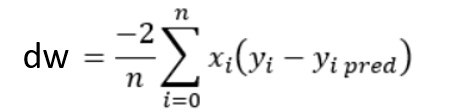

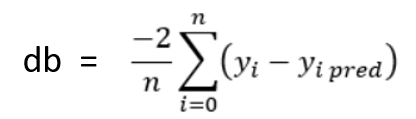

Linear regression

In [29]:
import numpy as np


In [30]:
class linear_regression():
  def __init__(self,learning_rate,no_of_iterations):
    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations


  def fit(self,X,Y):
    #no.of trainig examples and Futures
    self.m,self.n=X.shape #rows &colums
    #initializing weight &bias
    self.w=np.zeros(self.n)
    self.b=0
    self.X=X
    self.Y=Y

    #gradient descent
    for i in range(self.no_of_iterations):
      self.update_weights()



  def update_weights(self):
    Y_prediction=self.predict(self.X)
    #cal gradients
    dw=-(2*(self.X.T).dot(self.Y-Y_prediction))/self.m
    db=-2*np.sum(self.Y-Y_prediction)/self.m

    #updating weights
    self.w=self.w-self.learning_rate*dw
    self.b=self.b-self.learning_rate*db


  def predict(self,X):
    return X.dot(self.w)+self.b

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [32]:
salary_data=pd.read_csv('/content/salary_data.csv')

In [33]:
salary_data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [34]:
salary_data.shape

(30, 2)

In [35]:
X=salary_data.iloc[:,:-1].values
Y=salary_data.iloc[:,1].values

In [36]:
print(X)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [37]:
print(Y)

[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [38]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.33,random_state=2)

In [46]:
model=linear_regression(learning_rate=0.02,no_of_iterations=100)

In [47]:
model.fit(X_train,Y_train)

In [48]:
print('weight=',model.w[0])
print('bias=',model.b)

weight= 10941.258155090314
bias= 13499.045037502532


y=9514(x)+23697

In [49]:
test_data_prediction=model.predict(X_test)

In [50]:
print(test_data_prediction)

[ 27722.68063912  25534.4290081   62734.70673541  53981.70021134
  91181.97793864  79146.59396804 103217.36190924  46322.81950277
  35381.56134768  87899.60049212]


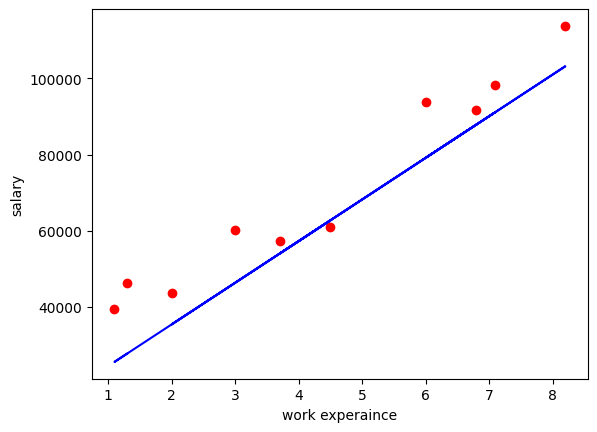

In [51]:
plt.scatter(X_test,Y_test,color='red')
plt.plot(X_test,test_data_prediction,color='blue')
plt.xlabel('work experaince')
plt.ylabel('salary')
plt.show()